In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os
import tensorflow_probability as tfp
tfd = tfp.distributions

tf.config.list_physical_devices('GPU')

[]

# importing data

In [3]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [4]:
df.loc[df['Name'] == "LH_0"].values[0][1:-1]

array([0.309, 0.979, 3.11234, 1.12194, 0.6685, 0.53182], dtype=object)

In [5]:
out_dir = "../grids/CO/20230327_1-2/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [6]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")
sim_names[:5], sim_names[-5:], sim_names[600:605], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 ['LH_600', 'LH_601', 'LH_602', 'LH_604', 'LH_605'],
 999)

In [11]:
num_samples = len(sim_names)
print(num_samples)
all_curves = np.empty((num_samples, 34, 74, 74, 74))
all_cosmologies = np.empty((num_samples, 6))
for ind, fil in enumerate(sim_names):
    if ind % 100 == 0:
        print(ind)
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
    all_curves[ind] = np.array(list(curves.values()))
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999
0
100
200
300
400
500
600
700
800
900


In [12]:
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves[:])), np.sum(np.isnan(all_cosmologies)))

(999, 34, 74, 74, 74) (999, 6)
0 0


In [13]:
np.savez("../grids/CO/20230327_1-2/all", all_curves=all_curves, all_cosmologies=all_cosmologies)

In [7]:
with np.load("../grids/CO/20230327_1-2/all.npz") as data:
    all_curves = data['all_curves']
    all_cosmologies = data['all_cosmologies']

In [8]:
num_samples = len(sim_names)
print(num_samples)
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves[:])), np.sum(np.isnan(all_cosmologies)))

999
(999, 34, 74, 74, 74) (999, 6)
0 0


In [9]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

train_x, val_x, test_x = map(lambda arr: np.transpose(arr, axes=[0, 2, 3, 4, 1]), [train_x, val_x, test_x])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 74, 74, 74, 34) (100, 74, 74, 74, 34) (50, 74, 74, 74, 34)
(849, 6) (100, 6) (50, 6)


In [ ]:
from scipy.fft import fftn

train_x, val_x, test_x = map(lambda arr: fftn(arr, axes=(1, 2, 3)), [train_x, val_x, test_x])
print(train_x.shape, val_x.shape, test_x.shape)

In [14]:
fftn(train_x[0:1, :, :, :, 0:1], axes=(1, 2, 3))

array([[[[[ 760008.44424194     -0.j        ],
          [  73563.46392096 +13945.81981636j],
          [ -21846.08079844 -10030.31719258j],
          ...,
          [   9126.77421314 +80445.53835194j],
          [ -21846.08079844 +10030.31719258j],
          [  73563.46392096 -13945.81981636j]],

         [[-123732.6626064 +101979.92277923j],
          [  77056.56081815 -36247.80590583j],
          [   3554.63888264 +63309.81474825j],
          ...,
          [ -65928.60016549  +1144.28857162j],
          [  52756.94829429 -32911.16170955j],
          [ -84766.49184713 +22553.40145544j]],

         [[ -44276.88640099 -73715.80970072j],
          [  19132.01175603 +22436.95685363j],
          [  82355.08233237   +955.6891887j ],
          ...,
          [  22159.88106599 -31744.78999563j],
          [  -5479.92736381 +66477.50649632j],
          [  57522.5511921  -60267.82436635j]],

         ...,

         [[  23225.02079565 +44867.2351004j ],
          [  39965.46208653 -14989.464304

In [10]:
train_x, val_x, test_x = map(lambda arr: np.nansum(arr, axis=(1)), [train_x, val_x, test_x])
print(train_x.shape, val_x.shape, test_x.shape)

(849, 74, 74, 34) (100, 74, 74, 34) (50, 74, 74, 34)


In [14]:
input_shape = (74, 74, 74, 34)
output_num = 6

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='leaky_relu', input_shape=input_shape),
  tf.keras.layers.Dense(32, activation='leaky_relu'),
  tf.keras.layers.Conv3D(32, kernel_size=(2, 2, 2), activation='relu'),
  tf.keras.layers.MaxPooling3D(pool_size=(3, 3, 3)),
  tf.keras.layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu'),
  tf.keras.layers.MaxPooling3D(pool_size=(3, 3, 3)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64, activation='leaky_relu'),
  tf.keras.layers.Dense(32, activation='leaky_relu'),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
# model.compile(loss='mse', optimizer='adam')
model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 74, 74, 74, 64)    2240      
                                                                 
 dense_7 (Dense)             (None, 74, 74, 74, 32)    2080      
                                                                 
 conv3d_2 (Conv3D)           (None, 73, 73, 73, 32)    8224      
                                                                 
 max_pooling3d_2 (MaxPooling  (None, 24, 24, 24, 32)   0         
 3D)                                                             
                                                                 
 conv3d_3 (Conv3D)           (None, 22, 22, 22, 32)    27680     
                                                                 
 max_pooling3d_3 (MaxPooling  (None, 7, 7, 7, 32)      0         
 3D)                                                  

In [15]:
# Train the model
history = model.fit(train_x, train_y, epochs=6, validation_data=(val_x, val_y))

Epoch 1/6


2023-04-01 23:17:13.425160: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 46788783936 exceeds 10% of free system memory.


27/27 [==============================] - 409s 15s/step - loss: 22.1224 - val_loss: 0.4365
Epoch 2/6
27/27 [==============================] - 400s 15s/step - loss: 0.4504 - val_loss: 0.3872
Epoch 3/6
27/27 [==============================] - 395s 15s/step - loss: 0.3493 - val_loss: 0.2383
Epoch 4/6
27/27 [==============================] - 396s 15s/step - loss: 0.2333 - val_loss: 0.1825
Epoch 5/6
27/27 [==============================] - 389s 14s/step - loss: 0.1965 - val_loss: 0.1720
Epoch 6/6
27/27 [==============================] - 380s 14s/step - loss: 0.1794 - val_loss: 0.1690


4/4 [==============================] - 2s 378ms/step


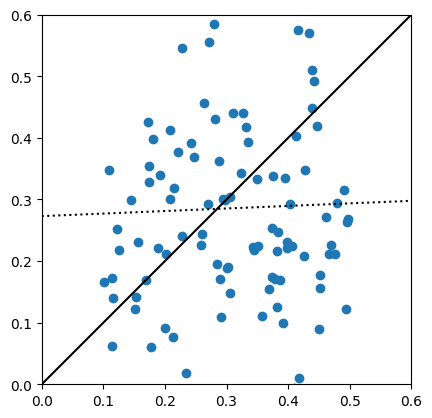

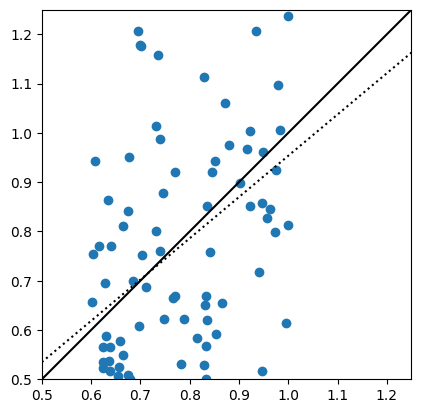

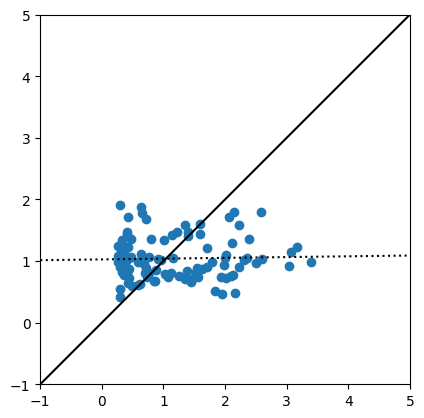

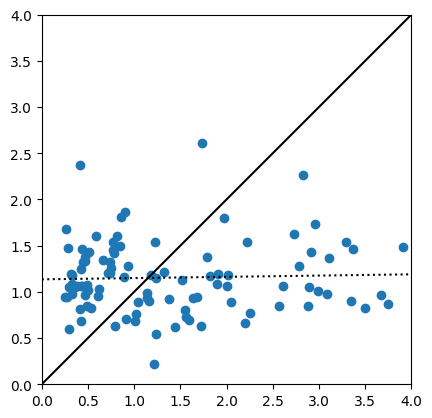

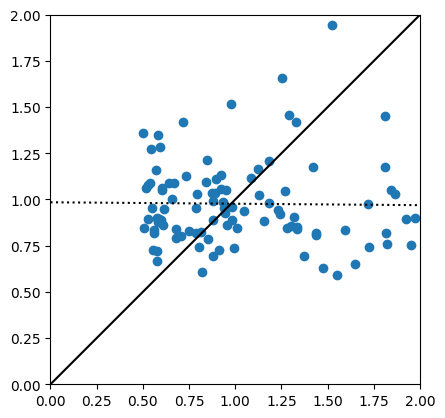

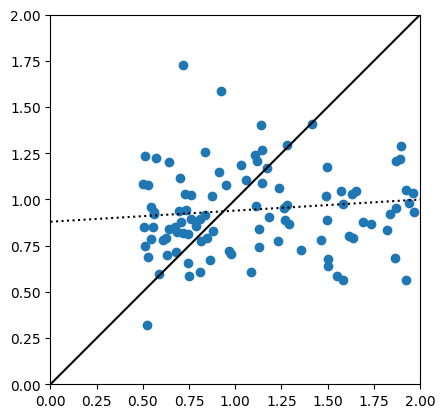

In [16]:
predictions = model.predict(val_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(val_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(val_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()